<style>
.jp-Notebook .jp-MarkdownCell,
.text_cell_render {
    font-size: 14px;
    line-height: 1.38;
}
.jp-CodeCell .cm-editor,
.jp-CodeCell pre,
.code_cell .CodeMirror {
    font-size: 13px !important;
    line-height: 1.30 !important;
}
</style>

# ECON 422: Macroeconomics & Machine Learning
## Machine Learning for Nuisance Components

This notebook follows the lecture note's progression:

1. use machine learning to construct **flexible controls**;
2. use **sample splitting / cross-fitting** so an observation does not train the nuisance model used on itself;
3. remember that cross-fitting gives **separation**, but does not by itself remove first-order sensitivity to nuisance estimation error.

For the outer cross-fitting folds,

$$
i\in I_k:
\qquad
\widehat f_i=\widehat f^{(-k)}(X_i).
$$

The held-out fold is temporary; it is **not** a final test sample.

The first illustration reproduces the two-fold random-forest arithmetic from the note.  
The second uses LASSO with a rich polynomial/interactions dictionary to show how flexible controls can be learned inside the same outer-fold rule.


## Setup for the nuisance-learning examples

We use the partially linear model

$$
Y_i=\theta_0D_i+g_0(X_i)+U_i,
\qquad
E[U_i\mid D_i,X_i]=0.
$$

To keep the random-forest and LASSO illustrations focused on a **single nuisance function**, the toy examples below impose

$$
E[D_i\mid X_i]=0.
$$

Then

$$
E[Y_i\mid X_i]
=
\theta_0E[D_i\mid X_i]+g_0(X_i)
=
g_0(X_i).
$$

So, **only for these teaching examples**, an ML regression of $Y$ on $X$ can be interpreted directly as learning $g_0(X)$. This restriction is a pedagogical simplification, not a defining assumption of the general partially linear model.

### Practice 1 - Create the estimation sample

The sample and folds match the random-forest illustration in the note.

The toy design also satisfies $E[D_i \mid X_i]=0$ within each fold. Therefore
$E[Y_i\mid X_i]=g_0(X_i)$, so the forest prediction can be read directly as a nuisance estimate.

Run the code below.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LassoCV
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor

pd.set_option(&quot;display.max_rows&quot;, 80)
pd.set_option(&quot;display.max_columns&quot;, 30)

theta0 = 2.0

data = pd.DataFrame({
    &quot;i&quot;: range(1, 9),
    &quot;X&quot;: [0, 0, 1, 1, 0, 0, 1, 1],
    &quot;D&quot;: [-1, 1, -1, 1, -0.5, 0.5, -0.5, 0.5],
    &quot;Y&quot;: [1, 5, 9, 13, 2, 4, 10, 12],
    &quot;Fold&quot;: [&quot;A&quot;]*4 + [&quot;B&quot;]*4
})

# In this toy PLM, E[D|X]=0 and g0(0)=3, g0(1)=11.
data[&quot;g0&quot;] = np.where(data[&quot;X&quot;].eq(0), 3.0, 11.0)

print(data.to_string(index=False))
print()
print(&quot;Check Y = theta0*D + g0:&quot;)
print(np.allclose(data[&quot;Y&quot;], theta0*data[&quot;D&quot;] + data[&quot;g0&quot;]))</pre>

In [ ]:
# Type Practice 1 here.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LassoCV
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor

pd.set_option('display.max_rows', 80)
pd.set_option('display.max_columns', 30)

theta0 = 2.0

data = pd.DataFrame({
    'i': range(1, 9),
    'X': [0, 0, 1, 1, 0, 0, 1, 1],
    'D': [-1, 1, -1, 1, -0.5, 0.5, -0.5, 0.5],
    'Y': [1, 5, 9, 13, 2, 4, 10, 12],
    'Fold': ['A']*4 + ['B']*4
})

# In this toy PLM, E[D|X]=0 and g0(0)=3, g0(1)=11.
data['g0'] = np.where(data['X'].eq(0), 3.0, 11.0)

print(data.to_string(index=False))
print()
print("Check Y = theta0*D + g0:")
print(np.allclose(data['Y'], theta0*data['D'] + data['g0']))

 i  X    D  Y Fold   g0
 1  0 -1.0  1    A  3.0
 2  0  1.0  5    A  3.0
 3  1 -1.0  9    A 11.0
 4  1  1.0 13    A 11.0
 5  0 -0.5  2    B  3.0
 6  0  0.5  4    B  3.0
 7  1 -0.5 10    B 11.0
 8  1  0.5 12    B 11.0

Check Y = theta0*D + g0:
True


### Practice 2 - Reproduce the Fold-B forest and construct g-hat for Fold A

Use the two bootstrap draws from the note. Each tree is fitted only on Fold B; their predictions are averaged for Fold A.

Because $E[D \mid X]=0$ in this toy example, the forest regression of $Y$ on $X$ targets $g_0(X)$.

Run the code below.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">def fit_tree_from_rows(row_ids):
    # .loc preserves repeated row IDs, reproducing the bootstrap draws in the note.
    boot = data.set_index(&quot;i&quot;).loc[row_ids].reset_index()
    tree = DecisionTreeRegressor(max_depth=1, random_state=0)
    tree.fit(boot[[&quot;X&quot;]], boot[&quot;Y&quot;])
    return tree

# Exact bootstrap draws used in the note for Fold B
B_draws = [
    [5, 5, 7, 8],
    [6, 6, 7, 8],
]

trees_B = [fit_tree_from_rows(draw) for draw in B_draws]

hold_A = data[&quot;Fold&quot;].eq(&quot;A&quot;)
pred_A_by_tree = np.column_stack([
    tree.predict(data.loc[hold_A, [&quot;X&quot;]])
    for tree in trees_B
])
g_hat_A = pred_A_by_tree.mean(axis=1)

check_A = data.loc[hold_A, [&quot;i&quot;, &quot;X&quot;, &quot;D&quot;, &quot;Y&quot;, &quot;g0&quot;]].copy()
check_A[&quot;Tree 1&quot;] = pred_A_by_tree[:, 0]
check_A[&quot;Tree 2&quot;] = pred_A_by_tree[:, 1]
check_A[&quot;g_hat_CF&quot;] = g_hat_A

print(check_A.to_string(index=False))</pre>

In [ ]:
# Type Practice 2 here.
def fit_tree_from_rows(row_ids):
    # .loc preserves repeated row IDs, reproducing the bootstrap draws in the note.
    boot = data.set_index('i').loc[row_ids].reset_index()
    tree = DecisionTreeRegressor(max_depth=1, random_state=0)
    tree.fit(boot[['X']], boot['Y'])
    return tree

# Exact bootstrap draws used in the note for Fold B
B_draws = [
    [5, 5, 7, 8],
    [6, 6, 7, 8],
]

trees_B = [fit_tree_from_rows(draw) for draw in B_draws]

hold_A = data['Fold'].eq('A')
pred_A_by_tree = np.column_stack([
    tree.predict(data.loc[hold_A, ['X']])
    for tree in trees_B
])
g_hat_A = pred_A_by_tree.mean(axis=1)

check_A = data.loc[hold_A, ['i', 'X', 'D', 'Y', 'g0']].copy()
check_A['Tree 1'] = pred_A_by_tree[:, 0]
check_A['Tree 2'] = pred_A_by_tree[:, 1]
check_A['g_hat_CF'] = g_hat_A

print(check_A.to_string(index=False))

 i  X    D  Y   g0  Tree 1  Tree 2  g_hat_CF
 1  0 -1.0  1  3.0     2.0     4.0       3.0
 2  0  1.0  5  3.0     2.0     4.0       3.0
 3  1 -1.0  9 11.0    11.0    11.0      11.0
 4  1  1.0 13 11.0    11.0    11.0      11.0


### Practice 3 - Swap the folds and pool the nuisance estimates

Now fit the two Fold-A trees and evaluate Fold B. Combining both directions gives one cross-fitted nuisance estimate $\widehat g_i^{\mathrm{CF}}$ per observation.

Run the code below.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;"># Exact bootstrap draws used in the note for Fold A
A_draws = [
    [1, 1, 3, 4],
    [2, 2, 3, 4],
]

trees_A = [fit_tree_from_rows(draw) for draw in A_draws]

hold_B = data[&quot;Fold&quot;].eq(&quot;B&quot;)
pred_B_by_tree = np.column_stack([
    tree.predict(data.loc[hold_B, [&quot;X&quot;]])
    for tree in trees_A
])
g_hat_B = pred_B_by_tree.mean(axis=1)

data[&quot;g_hat_CF&quot;] = np.nan
data.loc[hold_A, &quot;g_hat_CF&quot;] = g_hat_A
data.loc[hold_B, &quot;g_hat_CF&quot;] = g_hat_B
data[&quot;g_error&quot;] = data[&quot;g_hat_CF&quot;] - data[&quot;g0&quot;]

print(data.round(2).to_string(index=False))
print()
print(&quot;Cross-fitted nuisance vector:&quot;)
print(tuple(data[&quot;g_hat_CF&quot;].astype(int)))</pre>

In [ ]:
# Type Practice 3 here.
# Exact bootstrap draws used in the note for Fold A
A_draws = [
    [1, 1, 3, 4],
    [2, 2, 3, 4],
]

trees_A = [fit_tree_from_rows(draw) for draw in A_draws]

hold_B = data['Fold'].eq('B')
pred_B_by_tree = np.column_stack([
    tree.predict(data.loc[hold_B, ['X']])
    for tree in trees_A
])
g_hat_B = pred_B_by_tree.mean(axis=1)

data['g_hat_CF'] = np.nan
data.loc[hold_A, 'g_hat_CF'] = g_hat_A
data.loc[hold_B, 'g_hat_CF'] = g_hat_B
data['g_error'] = data['g_hat_CF'] - data['g0']

print(data.round(2).to_string(index=False))
print()
print("Cross-fitted nuisance vector:")
print(tuple(data["g_hat_CF"].astype(int)))

 i  X    D  Y Fold   g0  g_hat_CF  g_error
 1  0 -1.0  1    A  3.0       3.0      0.0
 2  0  1.0  5    A  3.0       3.0      0.0
 3  1 -1.0  9    A 11.0      11.0      0.0
 4  1  1.0 13    A 11.0      11.0      0.0
 5  0 -0.5  2    B  3.0       3.0      0.0
 6  0  0.5  4    B  3.0       3.0      0.0
 7  1 -0.5 10    B 11.0      11.0      0.0
 8  1  0.5 12    B 11.0      11.0      0.0

Cross-fitted nuisance vector:
(3, 3, 11, 11, 3, 3, 11, 11)


### Practice 4 - Visualize the cross-fitted nuisance estimates

The object of interest here is the nuisance component, not prediction of $Y$ itself.

Each observation receives $\widehat g_i^{\mathrm{CF}}$ from a forest trained on the other fold.

Run the code below.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">fig, ax = plt.subplots(figsize=(7.2, 4.0))

x_left = data[&quot;i&quot;] - 0.08
x_right = data[&quot;i&quot;] + 0.08

ax.scatter(
    x_left, data[&quot;g0&quot;],
    s=70, label=&quot;True nuisance g0(X)&quot;, zorder=3
)
ax.scatter(
    x_right, data[&quot;g_hat_CF&quot;],
    marker=&quot;x&quot;, s=80, linewidth=2.2,
    label=&quot;Cross-fitted nuisance g_hat&quot;, zorder=4
)

ax.set_xticks(data[&quot;i&quot;])
ax.set_xticklabels([
    f&quot;{i}\nFold {fold}&quot; for i, fold in zip(data[&quot;i&quot;], data[&quot;Fold&quot;])
])
ax.set(
    xlabel=&quot;Observation&quot;,
    ylabel=&quot;Nuisance component&quot;,
    title=&quot;Every observation receives an out-of-fold nuisance estimate&quot;
)
ax.legend()
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()</pre>

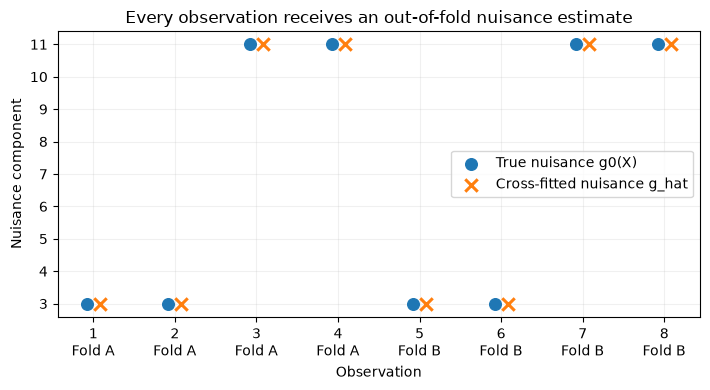

In [ ]:
# Type Practice 4 here.
fig, ax = plt.subplots(figsize=(7.2, 4.0))

x_left = data['i'] - 0.08
x_right = data['i'] + 0.08

ax.scatter(
    x_left, data['g0'],
    s=70, label='True nuisance g0(X)', zorder=3
)
ax.scatter(
    x_right, data['g_hat_CF'],
    marker='x', s=80, linewidth=2.2,
    label='Cross-fitted nuisance g_hat', zorder=4
)

ax.set_xticks(data['i'])
ax.set_xticklabels([
    f'{i}\nFold {fold}' for i, fold in zip(data['i'], data['Fold'])
])
ax.set(
    xlabel='Observation',
    ylabel='Nuisance component',
    title='Every observation receives an out-of-fold nuisance estimate'
)
ax.legend()
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()

## Flexible controls with LASSO

The note emphasizes that LASSO becomes a flexible-control method when we first
supply a **rich dictionary** of candidate terms. With two original controls, a
polynomial dictionary can contain

$$
X_1,\;X_2,\;X_1^2,\;X_1X_2,\;X_2^2,\ldots
$$

LASSO then shrinks many coefficients and may set many exactly to zero.

For this toy illustration, $D$ is constructed to be mean-zero conditional on $X$.
Hence $E[Y \mid X]=g_0(X)$, and the cross-fitted LASSO prediction can be interpreted directly as $\widehat g(X)$.

Cross-fitting wraps around the **whole pipeline**: feature construction,
standardization, tuning of the penalty, selection, and coefficient estimation.

### Practice 5 - Create nonlinear data for the LASSO illustration

The nuisance function contains nonlinear terms and an interaction. The learner sees only the original controls `X1` and `X2` and receives a rich polynomial dictionary.

For each observed $X$ pair, we create two observations with opposite values of $D$. Thus the sample is exactly balanced so that $E[D \mid X]=0$.

Run the code below.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">rng = np.random.default_rng(123)
n_base = 80

base = pd.DataFrame({
    &quot;X1&quot;: rng.uniform(-2, 2, size=n_base),
    &quot;X2&quot;: rng.uniform(-2, 2, size=n_base),
})

# Assign each X pair to one outer fold, then duplicate it with D=-0.25 and D=+0.25.
fold_labels = np.array([&quot;A&quot;] * (n_base // 2) + [&quot;B&quot;] * (n_base - n_base // 2))
rng.shuffle(fold_labels)
base[&quot;Fold&quot;] = fold_labels

lasso_data = base.loc[base.index.repeat(2)].reset_index(drop=True)
lasso_data[&quot;D&quot;] = np.tile([-0.25, 0.25], n_base)

lasso_data[&quot;g0&quot;] = (
    1.2 * lasso_data[&quot;X1&quot;]
    - 0.7 * lasso_data[&quot;X1&quot;]**2
    + 0.9 * lasso_data[&quot;X1&quot;] * lasso_data[&quot;X2&quot;]
    + 0.5 * lasso_data[&quot;X2&quot;]**3
)

theta0 = 2.0
lasso_data[&quot;Y&quot;] = theta0 * lasso_data[&quot;D&quot;] + lasso_data[&quot;g0&quot;]

print(lasso_data.head(8).round(3).to_string(index=False))
print()
print(&quot;For each repeated X pair, D averages to zero by construction.&quot;)</pre>

In [ ]:
# Type Practice 5 here.
rng = np.random.default_rng(123)
n_base = 80

base = pd.DataFrame({
    "X1": rng.uniform(-2, 2, size=n_base),
    "X2": rng.uniform(-2, 2, size=n_base),
})

# Assign each X pair to one outer fold, then duplicate it with D=-0.25 and D=+0.25.
fold_labels = np.array(["A"] * (n_base // 2) + ["B"] * (n_base - n_base // 2))
rng.shuffle(fold_labels)
base["Fold"] = fold_labels

lasso_data = base.loc[base.index.repeat(2)].reset_index(drop=True)
lasso_data["D"] = np.tile([-0.25, 0.25], n_base)

lasso_data["g0"] = (
    1.2 * lasso_data["X1"]
    - 0.7 * lasso_data["X1"]**2
    + 0.9 * lasso_data["X1"] * lasso_data["X2"]
    + 0.5 * lasso_data["X2"]**3
)

theta0 = 2.0
lasso_data["Y"] = theta0 * lasso_data["D"] + lasso_data["g0"]

print(lasso_data.head(8).round(3).to_string(index=False))
print()
print("For each repeated X pair, D averages to zero by construction.")

    X1     X2 Fold     D     g0      Y
 0.729 -1.976    B -0.25 -4.655 -5.155
 0.729 -1.976    B  0.25 -4.655 -4.155
-1.785  1.026    A -0.25 -5.479 -5.979
-1.785  1.026    A  0.25 -5.479 -4.979
-1.119 -1.690    A -0.25 -2.929 -3.429
-1.119 -1.690    A  0.25 -2.929 -2.429
-1.263 -0.040    B -0.25 -2.585 -3.085
-1.263 -0.040    B  0.25 -2.585 -2.085

For each repeated X pair, D averages to zero by construction.


### Practice 6 - Fit LASSO on Fold B and inspect selected nuisance terms

The pipeline constructs powers/interactions through degree 4, standardizes them, and tunes the LASSO penalty using cross-validation inside Fold B.

Because $E[D \mid X]=0$, fitting $Y$ on the flexible $X$-dictionary targets $g_0(X)$.

Run the code below.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">def make_lasso_pipeline(degree=4):
    return Pipeline([
        (&quot;poly&quot;, PolynomialFeatures(degree=degree, include_bias=False)),
        (&quot;scale&quot;, StandardScaler()),
        (&quot;lasso&quot;, LassoCV(cv=3, max_iter=20000))
    ])

features = [&quot;X1&quot;, &quot;X2&quot;]
train_B = lasso_data[&quot;Fold&quot;].eq(&quot;B&quot;)
hold_A = lasso_data[&quot;Fold&quot;].eq(&quot;A&quot;)

lasso_B = make_lasso_pipeline(degree=4)
lasso_B.fit(lasso_data.loc[train_B, features], lasso_data.loc[train_B, &quot;Y&quot;])

poly_names = lasso_B.named_steps[&quot;poly&quot;].get_feature_names_out(features)
coef_B = lasso_B.named_steps[&quot;lasso&quot;].coef_

selected_B = pd.DataFrame({
    &quot;candidate term&quot;: poly_names,
    &quot;coefficient&quot;: coef_B
})
selected_B = selected_B.loc[selected_B[&quot;coefficient&quot;].abs() &gt; 1e-8]
selected_B = selected_B.reindex(
    selected_B[&quot;coefficient&quot;].abs().sort_values(ascending=False).index
)

print(&quot;Selected nuisance terms when fitting on Fold B:&quot;)
print(selected_B.round(3).to_string(index=False))
print(f&quot;Chosen lambda (alpha): {lasso_B.named_steps[&#x27;lasso&#x27;].alpha_:.5f}&quot;)</pre>

In [ ]:
# Type Practice 6 here.
def make_lasso_pipeline(degree=4):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scale", StandardScaler()),
        ("lasso", LassoCV(cv=3, max_iter=20000))
    ])

features = ["X1", "X2"]
train_B = lasso_data["Fold"].eq("B")
hold_A = lasso_data["Fold"].eq("A")

lasso_B = make_lasso_pipeline(degree=4)
lasso_B.fit(lasso_data.loc[train_B, features], lasso_data.loc[train_B, "Y"])

poly_names = lasso_B.named_steps["poly"].get_feature_names_out(features)
coef_B = lasso_B.named_steps["lasso"].coef_

selected_B = pd.DataFrame({
    "candidate term": poly_names,
    "coefficient": coef_B
})
selected_B = selected_B.loc[selected_B["coefficient"].abs() > 1e-8]
selected_B = selected_B.reindex(
    selected_B["coefficient"].abs().sort_values(ascending=False).index
)

print("Selected nuisance terms when fitting on Fold B:")
print(selected_B.round(3).to_string(index=False))
print(f"Chosen lambda (alpha): {lasso_B.named_steps['lasso'].alpha_:.5f}")

Selected nuisance terms when fitting on Fold B:
candidate term  coefficient
          X2^3        1.382
            X1        1.208
          X1^2       -0.738
         X1 X2        0.736
          X1^3        0.001
Chosen lambda (alpha): 0.00307


### Practice 7 - Cross-fit the entire LASSO pipeline

Repeat the whole learning procedure in both directions. A held-out observation never participates in feature scaling, penalty tuning, variable selection, or coefficient estimation for its own nuisance estimate.

Run the code below.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">lasso_data[&quot;g_hat_CF&quot;] = np.nan
selected_terms = {}

for held_out in [&quot;A&quot;, &quot;B&quot;]:
    train = lasso_data[&quot;Fold&quot;].ne(held_out)
    test = lasso_data[&quot;Fold&quot;].eq(held_out)

    model = make_lasso_pipeline(degree=4)
    model.fit(lasso_data.loc[train, features], lasso_data.loc[train, &quot;Y&quot;])
    lasso_data.loc[test, &quot;g_hat_CF&quot;] = model.predict(
        lasso_data.loc[test, features]
    )

    names = model.named_steps[&quot;poly&quot;].get_feature_names_out(features)
    coef = model.named_steps[&quot;lasso&quot;].coef_
    selected_terms[held_out] = list(names[np.abs(coef) &gt; 1e-8])

for held_out, terms in selected_terms.items():
    training_fold = &quot;B&quot; if held_out == &quot;A&quot; else &quot;A&quot;
    print(f&quot;Construct g_hat for Fold {held_out} using model trained on Fold {training_fold}:&quot;)
    print(&quot;  Selected terms:&quot;, &quot;, &quot;.join(terms))
    print()

fig, ax = plt.subplots(figsize=(5.6, 4.4))
ax.scatter(lasso_data[&quot;g0&quot;], lasso_data[&quot;g_hat_CF&quot;], alpha=0.55, s=28)

limits = [
    min(lasso_data[&quot;g0&quot;].min(), lasso_data[&quot;g_hat_CF&quot;].min()),
    max(lasso_data[&quot;g0&quot;].max(), lasso_data[&quot;g_hat_CF&quot;].max()),
]
ax.plot(limits, limits, &quot;--&quot;, label=&quot;45-degree line&quot;)
ax.set(
    xlabel=&quot;True nuisance g0(X)&quot;,
    ylabel=&quot;Cross-fitted nuisance g_hat(X)&quot;,
    title=&quot;Rich controls + LASSO + outer cross-fitting&quot;
)
ax.legend()
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()</pre>

Construct g_hat for Fold A using model trained on Fold B:
  Selected terms: X1, X1^2, X1 X2, X1^3, X2^3

Construct g_hat for Fold B using model trained on Fold A:
  Selected terms: X1, X1^2, X1 X2, X2^3, X1^4, X1^3 X2



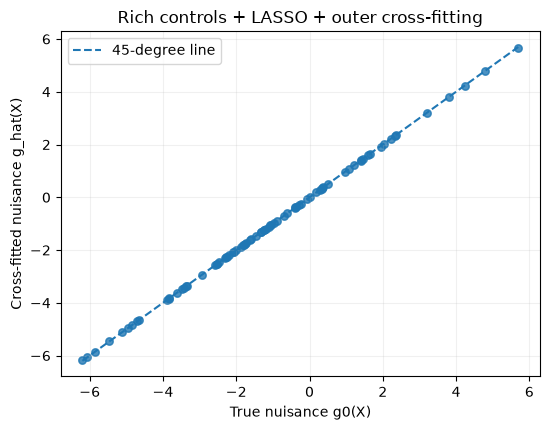

In [ ]:
# Type Practice 7 here.
lasso_data["g_hat_CF"] = np.nan
selected_terms = {}

for held_out in ["A", "B"]:
    train = lasso_data["Fold"].ne(held_out)
    test = lasso_data["Fold"].eq(held_out)

    model = make_lasso_pipeline(degree=4)
    model.fit(lasso_data.loc[train, features], lasso_data.loc[train, "Y"])
    lasso_data.loc[test, "g_hat_CF"] = model.predict(
        lasso_data.loc[test, features]
    )

    names = model.named_steps["poly"].get_feature_names_out(features)
    coef = model.named_steps["lasso"].coef_
    selected_terms[held_out] = list(names[np.abs(coef) > 1e-8])

for held_out, terms in selected_terms.items():
    training_fold = "B" if held_out == "A" else "A"
    print(f"Construct g_hat for Fold {held_out} using model trained on Fold {training_fold}:")
    print("  Selected terms:", ", ".join(terms))
    print()

fig, ax = plt.subplots(figsize=(5.6, 4.4))
ax.scatter(lasso_data["g0"], lasso_data["g_hat_CF"], alpha=0.55, s=28)

limits = [
    min(lasso_data["g0"].min(), lasso_data["g_hat_CF"].min()),
    max(lasso_data["g0"].max(), lasso_data["g_hat_CF"].max()),
]
ax.plot(limits, limits, "--", label="45-degree line")
ax.set(
    xlabel="True nuisance g0(X)",
    ylabel="Cross-fitted nuisance g_hat(X)",
    title="Rich controls + LASSO + outer cross-fitting"
)
ax.legend()
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()

## Why cross-fitting alone is not enough

The RF and LASSO examples above imposed $E[D \mid X]=0$ **only to make direct nuisance learning transparent**.

For the general partially linear model, we do not impose that toy restriction here. Cross-fitting separates the nuisance-learning sample from the observations used for the target-parameter step, but it does **not** by itself make nuisance estimation error negligible.

For the naive moment

$$
m(W_i;\theta,g)
=
D_i\{Y_i-\theta D_i-g(X_i)\},
$$

the sensitivity to the nuisance function is

$$
\frac{\partial m}{\partial g}=-D_i,
\qquad
E\!\left[\frac{\partial m}{\partial g}\right]=-E[D_i],
$$

which is generally not zero.

The next code cell illustrates the rate comparison from the note. An
$O_p(n^{-1/4})$ nuisance error is consistent, but it vanishes much more slowly
than the $O_p(n^{-1/2})$ variation used for standard root-$n$ inference.

### Practice 8 - Compare $n^{-1/4}$ with $n^{-1/2}$

At the same sample size, the slower nuisance rate can remain much larger. In particular, $10{,}000^{-1/4}=100^{-1/2}=0.1$.

Run the code below.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">rates = pd.DataFrame({&quot;n&quot;: [100, 1_000, 10_000, 100_000, 1_000_000]})
rates[&quot;n^(-1/4)&quot;] = rates[&quot;n&quot;] ** (-1/4)
rates[&quot;n^(-1/2)&quot;] = rates[&quot;n&quot;] ** (-1/2)

print(rates.round(4).to_string(index=False))
print()
print(&quot;10,000^(-1/4) =&quot;, 10_000 ** (-1/4))
print(&quot;100^(-1/2)    =&quot;, 100 ** (-1/2))

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.loglog(rates[&quot;n&quot;], rates[&quot;n^(-1/4)&quot;], marker=&quot;o&quot;, label=r&quot;$n^{-1/4}$&quot;)
ax.loglog(rates[&quot;n&quot;], rates[&quot;n^(-1/2)&quot;], marker=&quot;o&quot;, label=r&quot;$n^{-1/2}$&quot;)
ax.set(
    xlabel=&quot;Sample size n&quot;,
    ylabel=&quot;Illustrative error magnitude&quot;,
    title=&quot;A slower nuisance rate can dominate root-n variation&quot;
)
ax.legend()
ax.grid(alpha=0.22, which=&quot;both&quot;)
plt.tight_layout()
plt.show()
</pre>

      n  n^(-1/4)  n^(-1/2)
    100    0.3162    0.1000
   1000    0.1778    0.0316
  10000    0.1000    0.0100
 100000    0.0562    0.0032
1000000    0.0316    0.0010

10,000^(-1/4) = 0.1
100^(-1/2)    = 0.1


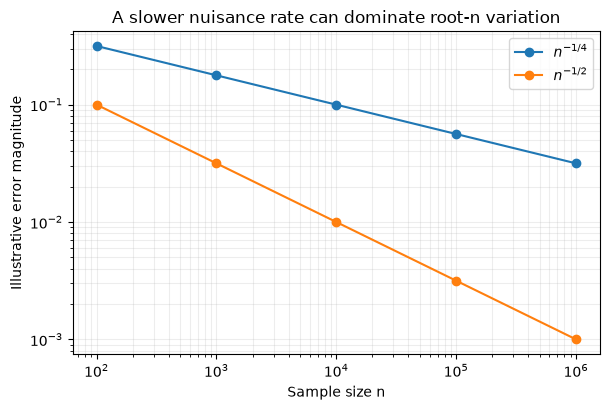

In [ ]:
# Type Practice 8 here.
rates = pd.DataFrame({"n": [100, 1_000, 10_000, 100_000, 1_000_000]})
rates["n^(-1/4)"] = rates["n"] ** (-1/4)
rates["n^(-1/2)"] = rates["n"] ** (-1/2)

print(rates.round(4).to_string(index=False))
print()
print("10,000^(-1/4) =", 10_000 ** (-1/4))
print("100^(-1/2)    =", 100 ** (-1/2))

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.loglog(rates["n"], rates["n^(-1/4)"], marker="o", label=r"$n^{-1/4}$")
ax.loglog(rates["n"], rates["n^(-1/2)"], marker="o", label=r"$n^{-1/2}$")
ax.set(
    xlabel="Sample size n",
    ylabel="Illustrative error magnitude",
    title="A slower nuisance rate can dominate root-n variation"
)
ax.legend()
ax.grid(alpha=0.22, which="both")
plt.tight_layout()
plt.show()

### Takeaway

- **Toy simplification:** in the RF and LASSO examples, $E[D \mid X]=0$, so $g_0(X)=E[Y\mid X]$ and the nuisance function can be learned directly from $Y$ on $X$.
- **Flexible controls:** forests learn nonlinear splits; LASSO selects from a rich dictionary.
- **Cross-fitting:** separates nuisance learning from the observation on which the nuisance estimate is evaluated.
- **Nested tuning:** hyperparameters are selected only inside the current outer training sample.
- **Cross-fitting is not orthogonality:** outside the toy $E[D \mid X]=0$ simplification, a nonzero first-order sensitivity can transmit a slowly vanishing nuisance error into target-parameter inference.

The next note introduces Neyman orthogonalization, which targets that remaining first-order sensitivity.

## Exercise - Nested tuning inside cross-fitting

The DGP below creates a nonlinear conditional mean. Use five outer folds for
cross-fitting. Within each outer training sample, use three-fold cross-validation
to select `max_depth` from $\{1,2,3,4\}$. Then report the out-of-fold mean squared error,

$$
\operatorname{MSE}_{\mathrm{OOF}}
=
\frac{1}{n}\sum_{i=1}^n(y_i-\widehat f_i)^2.
$$


### Exercise DGP

Copy and paste the exercise DGP supplied separately. It must create `X_ex` and `y_ex`.

In [ ]:
# Paste the DGP from Quizzes '(Sep23) Exercise'.
rng_ex = np.random.default_rng(42)
n_ex = 500
X_ex = rng_ex.uniform(-2, 2, size=(n_ex, 2))

f_ex = np.sin(1.5*X_ex[:, 0]) + 0.6*X_ex[:, 1]**2
y_ex = f_ex + rng_ex.normal(scale=0.35, size=n_ex)

### Complete the code

#### Hints

- **DGP and dimensions.** `len(y_ex)` must equal `X_ex.shape[0]`.
- **Outer cross-fitting loop.** `train_idx` fits the workflow; `hold_idx` receives predictions.
- **Inner cross-validation.** The target supplied to `.fit()` is `y_ex` restricted to `train_idx`.
- **Out-of-fold prediction storage.** Predict only on `hold_idx`; use the same parameter name as in `param_grid`.
- **MSE and completeness check.** Compare `y_ex` with the pooled out-of-fold predictions and verify finite values.
- **Interpretation.** Explain why the outer held-out fold must not enter `GridSearchCV`.


In [ ]:
n_ex = len(y_ex)
oof_ex = np.empty(n_ex)
chosen_depths = []
outer = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, hold_idx in outer.split(X_ex):
    search = GridSearchCV(
        DecisionTreeRegressor(random_state=42),
        param_grid={"max_depth": [1, 2, 3, 4]},
        cv=3,
        scoring="neg_mean_squared_error"
    )
    search.fit(X_ex[train_idx], y_ex[train_idx])
    oof_ex[hold_idx] = search.predict(X_ex[hold_idx])
    chosen_depths.append(search.best_params_["max_depth"])

mse_ex = np.mean((y_ex - oof_ex)**2)
assert np.isfinite(oof_ex).all()

print("Chosen depths:", chosen_depths)
print(f"Out-of-fold MSE: {mse_ex:.3f}")
